## Processamento Digital de Imagens - PDI - 2026.1

### Prof. Francisco Zampirolli
### Prof. Celso Kurashima



***

# Lab 8 - Segmentação Morfológica *Watershed*

### Tranformada de Distância, e Rotulação (*Label*)

***


#### ...
- Estude detalhadamente os exemplos abaixo, e analise o que é feito passo a passo nos processos de **Rotulação** e de **Segmentação**.

In [26]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print(cv2.__version__)

4.12.0


## Implementação de `morph.py`



In [5]:
def label0(f,b=np.ones((3,3),dtype='uint8')):
    """This function will be calculate label of each connect component
    input:
      - f: input image
      - b: structure element
    output:
      - y: image with op
    """
    h,w = f.shape
    bh, bw = b.shape

    g = np.zeros(f.shape).astype(int)
    cor = 1
    pilha = []
    for x in range(h): # varre as linhas da imagem
     for y in range(w):  # varre as colunas da image

      if (f[x,y]) and not g[x,y]: # buscar pixel de objeto não pintado

        pilha.append([x,y]) # colocar na pilha pixel p=[x,y]

        while pilha: # laço para pintar todos os pixel de cada objeto com cor

          i,j=pilha.pop() # retirar da pilha pixel q=[i,j]

          g[i,j] = cor # pinta

          # para cada vizinho de (i,j)
          for bx in range(bh):
            for by in range(bw):
              if b[bx,by]: # considero apenas vizinho >0
                viz_x = int(i + bx - bh/2 + 0.5)
                viz_y = int(j + by - bw/2 + 0.5)
                # verificar o domínion da image
                if 0 <= viz_x < h and 0 <= viz_y < w:

                  # colocar na pilha se é objeto e não foi pintado
                  if f[viz_x, viz_y] and not g[viz_x, viz_y]:
                      pilha.append([viz_x, viz_y]) # somente pixels não visitados e =1

        cor+=1 # incremento para pintar o próximo objeto
    return g

In [6]:
from morph import *

In [7]:
help(mm.label0)

Help on function label0 in module morph:

label0(f, b=array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8))
    This function will be calculate label of each connect component
    input:
      - f: input image
      - b: structure element
    output:
      - y: image with op



In [8]:
import inspect
print(inspect.getsource(mm.label0))

  @staticmethod
  def label0(f,b=np.ones((3,3),dtype='uint8')):
    """This function will be calculate label of each connect component
    input:
      - f: input image
      - b: structure element
    output:
      - y: image with op
    """
    h,w = f.shape
    bh, bw = b.shape

    g = np.zeros(f.shape).astype(int)
    cor = 1
    pilha = []
    for x in range(h):
     for y in range(w):

      if (f[x,y]) and not g[x,y]: # buscar pixel de objeto não pintado

        pilha.append([x,y]) # colocar na pilha pixel p=[x,y]

        while pilha: # laço para pintar todos os pixel de cada objeto com cor
          i,j=pilha.pop() # retirar da pilha pixel q=[i,j]
          g[i,j] = cor

          # para cada vizinho de (i,j)
          for bx in range(bh):
            for by in range(bw):
              if b[bx,by]:
                viz_x = int(i + bx - bh/2 + 0.5)
                viz_y = int(j + by - bw/2 + 0.5)
                # verificar o domínion da image
                if 0 <= viz_x < h

In [9]:
help(mm.label)

Help on function label in module morph:

label(f)
    This function will be calculate label of each connect component
    input:
      - f: input image
    output:
      - y: image with op



In [10]:
import inspect
print(inspect.getsource(mm.label))

  @staticmethod
  def label(f):
    """This function will be calculate label of each connect component
    input:
      - f: input image
    output:
      - y: image with op
    """
    num_labels, labels_im = cv2.connectedComponents(f)
    return labels_im



# Exemplo: Implementação do OpenCV

## connectedComponents

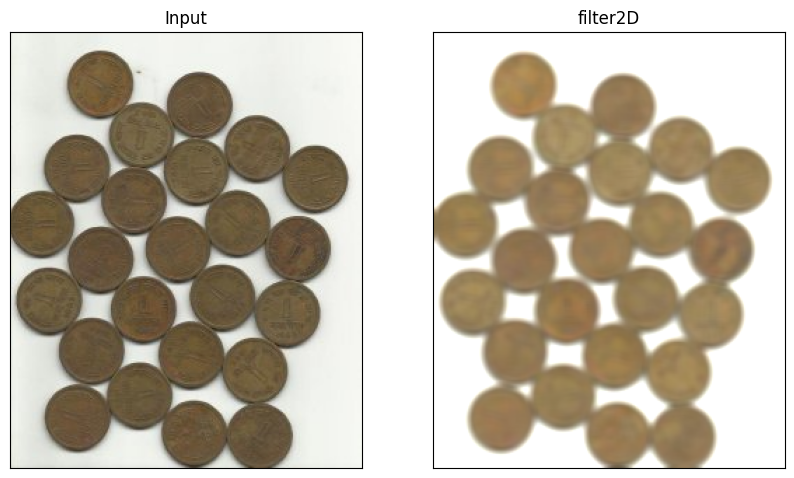

In [17]:
#
import numpy as np
import cv2
from matplotlib import pyplot as plt

img = cv2.imread('../archives/images/water_coins.png')

kernel = np.ones((6,6),np.float32)/25

filter2D = cv2.filter2D(img,-1,kernel)

blur = cv2.blur(img,(5,5))

gaussianBlur = cv2.GaussianBlur(img,(5,5),0)

median = cv2.medianBlur(img,5)

bilateralFilter = cv2.bilateralFilter(img,13,99,99)

plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(img,"gray"),plt.title('Input')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(filter2D,"gray"),plt.title('filter2D')
plt.xticks([]), plt.yticks([])
plt.show()


In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

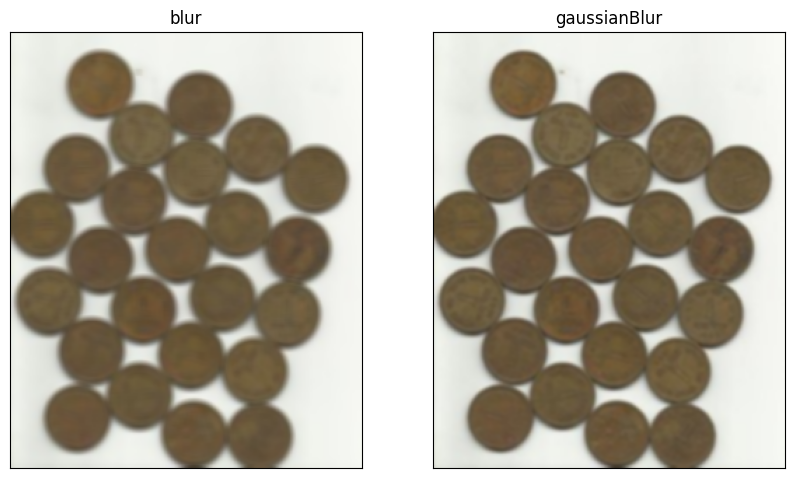

In [18]:
plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(blur,"gray"),plt.title('blur')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(gaussianBlur,"gray"),plt.title('gaussianBlur')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

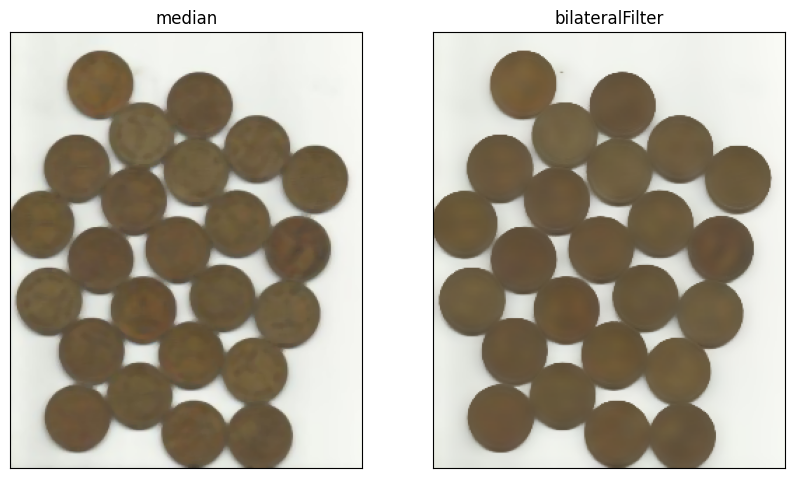

In [19]:
plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(median,"gray"),plt.title('median')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(bilateralFilter,"gray"),plt.title('bilateralFilter')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

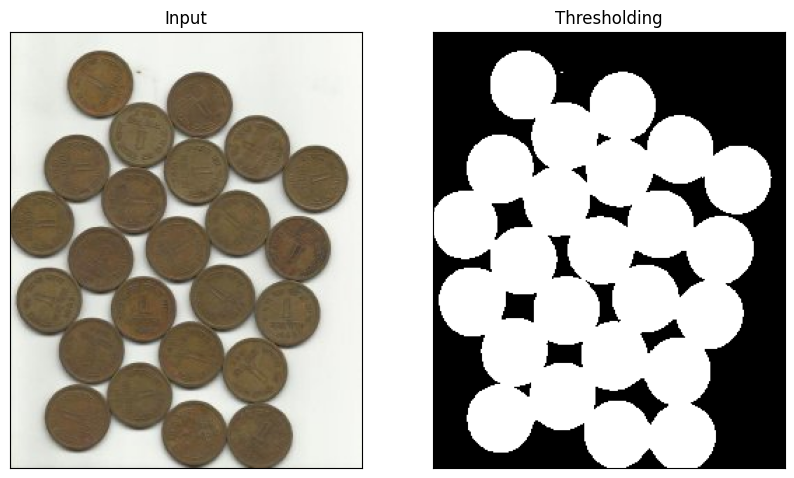

In [20]:
#img = bilateralFilter

gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(img,"gray"),plt.title('Input')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(thresh,"gray"),plt.title('Thresholding')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [21]:
# noise removal
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel, iterations = 2)

# sure background area
sure_bg = cv2.dilate(opening,kernel,iterations=3)

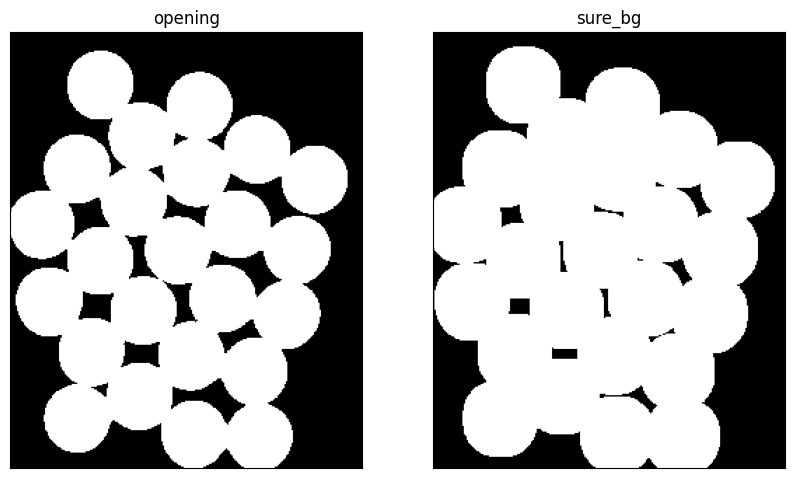

In [22]:
plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(opening,"gray"),plt.title('opening')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sure_bg,"gray"),plt.title('sure_bg')
plt.xticks([]), plt.yticks([])
plt.show()

In [23]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [24]:
# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
ret, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)

# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

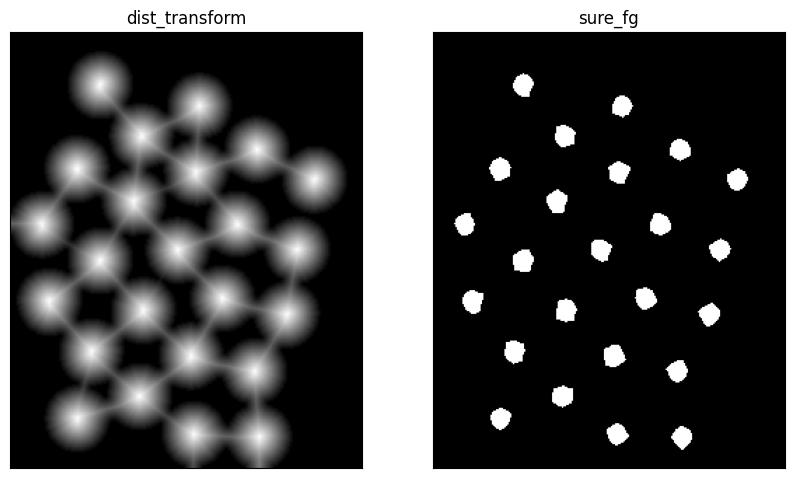

In [25]:
plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(dist_transform,"gray"),plt.title('dist_transform')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(sure_fg,"gray"),plt.title('sure_fg')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [ ]:
plt.figure(figsize=(10,6))
plt.xticks([]), plt.yticks([])
plt.imshow(unknown,"gray")

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [ ]:
# Marker labelling
#ret, markers = cv2.connectedComponents(sure_fg)
markers = mm.label(sure_fg)

# Add one to all labels so that sure background is not 0, but 1
markers = markers+1

# Now, mark the region of unknown with zero
markers[unknown==255] = 0

plt.figure(figsize=(10,6))

plt.imshow(markers,"gray"),plt.title('Label')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [ ]:
plt.figure(figsize=(10,6))
plt.imshow(markers,"pink"),plt.title('markers')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [ ]:
markers = cv2.watershed(img,markers)
plt.figure(figsize=(10,6))
plt.imshow(markers,"gray"),plt.title('markers')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

In [ ]:
img[markers == -1] = [255,0,255]

plt.figure(figsize=(10,6))
plt.imshow(img,"gray"),plt.title('img')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

#### Como separar apenas uma moeda? *A moeda numero (7)*?

In [ ]:
# Utilize os rótulos!!!
output_img = np.zeros_like(img)
output_img[markers == 7] = img[markers == 7]

plt.figure(figsize=(10,6))
plt.imshow(output_img)
plt.xticks([]), plt.yticks([])
plt.title('Objeto com rótulo 7')
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

## Segmentação e Rotulação com Implementação do OpenCV

### Exemplo utilizando *findContours*

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
print(cv2.__version__)

# findContours

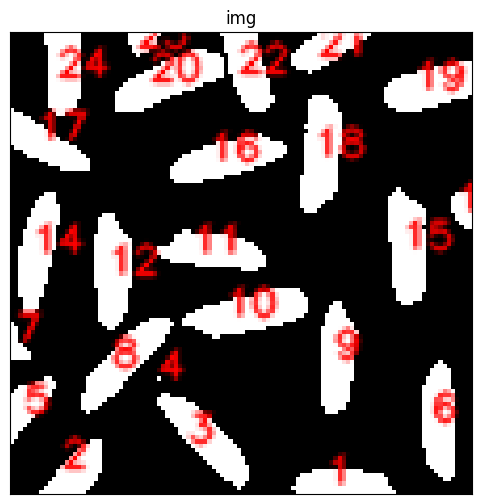

In [28]:
# mude o padrao aqui
padrao = cv2.RETR_LIST
font = cv2.FONT_HERSHEY_SIMPLEX

f = cv2.imread('../archives/images/rice.png',0)
img_teste = f[100:210,100:210]

T,img_teste = cv2.threshold(img_teste,0,255,cv2.THRESH_OTSU) #<<<<<<<<<<

img_canny = cv2.Canny(img_teste, 100, 200)
cont, _ = cv2.findContours(img_teste.copy(), padrao, cv2.CHAIN_APPROX_SIMPLE)

color_img = cv2.cvtColor(img_teste, cv2.COLOR_GRAY2RGB)

for k,c in enumerate(cont):
    x,y,w,h = cv2.boundingRect(c)
    cv2.putText(color_img, str(k+1),(x+w//3, y+h//2), font, 0.3,(255,0,0),1,cv2.LINE_AA)

plt.figure(figsize=(10,6))
plt.imshow(color_img,"gray"),plt.title('img')
plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

## Segmentação utilizando *morph.py*

### Exemplo utilizando *mm.show*

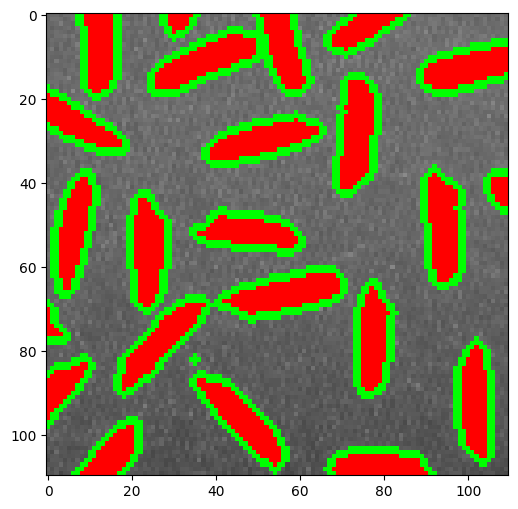

In [27]:
f0 = cv2.imread('../archives/images/rice.png')[100:210,100:210]
f = cv2.imread('../archives/images/rice.png',0)
img_teste = f[100:210,100:210]
T,img_teste = cv2.threshold(img_teste,0,255,cv2.THRESH_OTSU) #<<<<<<<<<<
img_canny = cv2.Canny(img_teste, 100, 200)

plt.figure(figsize=(10,6))
mm.show(f0,img_teste,mm.gradm(img_teste,mm.secross()))

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

## Segmentação e Rotulação utilizando *morph.py*

### Exemplo utilizando *mm.lblshow*

In [ ]:
import inspect
print(inspect.getsource(mm.lblshow))

In [ ]:
f = cv2.imread('../archives/images/rice.png',0)
img_teste = f[100:210,100:210]
T,img_teste = cv2.threshold(img_teste,0,255,cv2.THRESH_OTSU) #<<<<<<<<<<

plt.figure(figsize=(10,6))
mm.lblshow(img_teste)

In [ ]:
# Comente / analise / compare / explique aqui este processo e resultados.

## 3.a

(3.a). Elabore um programa para realizar as operações passo a passo da Segmentação
Morfológica WATERSHED, sobre (i) a imagem em grupo dos integrantes da equipe bem
como (ii) na imagem dos avatares, e apresente os resultados que segmente cada pessoa da
imagem e cada avatar respectivamente. Neste programa escolha um ou mais filtros para
a remoção de ruídos antes do processo de limiarização. Elabore uma análise detalhada de
cada passo da segmentação, quanto à Limiarização, à Transformada de Distância, e ao
processo de Rotulação.

## 3.b

(3.b). Elabore um novo programa para complementar o código anterior tal que a
imagem gerada seja composta pela imagem original, com os contornos das
pessoas/objetos sementadas e rotuladas, e um texto identificando cada
pessoa/objeto segmentada.

## 3.c

(3.c). Elabore um programa para realizar continuamente sobre a imagem da WEBCAM as
operações do programa acima da segmentação morfológica, mostrando na tela em tempo
real a imagem original com sobreposição dos contornos da segmentação obtida e texto de
identificação. Grave um video demonstrativo com os integrantes da equipe todos juntos
utilizando este programa com a webcam. Elabore uma análise detalhada e explique os
artefatos ocorridos.